In [ ]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"

import jax
import jax.numpy as jnp
import numpy as np
import mujoco
import mediapy as media
import pathlib
from omegaconf import OmegaConf

from kandel.utility.checkpoint_loader import load_policy
from kandel.utility.checkpoint_loader import load_playground_environment
from kandel.utility import running_statistics

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import scienceplots

plt.style.use(["science", "grid"])

## Gait analysis

In [3]:
def load_checkpoint(run_dir):
    """Load the latest checkpoint from a run directory."""

    run_path = pathlib.Path(run_dir)

    # Find latest checkpoint
    generation_folders = list(run_path.glob("generation_*"))
    if not generation_folders:
        return None

    generation_numbers = []
    for f in generation_folders:
        try:
            num = int(f.name.split("_")[1])
            generation_numbers.append(num)
        except:
            continue

    if not generation_numbers:
        return None

    latest_checkpoint = max(generation_numbers)

    if 499 in generation_numbers:
        latest_checkpoint = 499
    elif 500 in generation_numbers:
        latest_checkpoint = 500
    else:
        raise

    # Load policy and environment
    try:
        policy, policy_params = load_policy(
            run_dir, latest_checkpoint, policy_id=0
        )
        env, norm_state, cfg = load_playground_environment(
            run_dir, latest_checkpoint
        )
        norm_state = norm_state.replace(count=0)

        return {
            "policy": policy,
            "policy_params": policy_params,
            "env": env,
            "norm_state": norm_state,
            "cfg": cfg,
            "checkpoint": latest_checkpoint,
            "run_dir": run_dir,
        }
    except Exception as e:
        print(f"Failed to load {run_dir}: {e}")
        return None


def evaluate_single_run(checkpoint_data, episode_length=1000, seed=0):
    """Evaluate a single checkpoint and return raw metrics."""
    policy = checkpoint_data["policy"]
    policy_params = checkpoint_data["policy_params"]
    env = checkpoint_data["env"]
    norm_state = checkpoint_data["norm_state"]
    cfg = checkpoint_data["cfg"]

    # Jit functions
    env_reset_fn = jax.jit(env.reset)
    env_step_fn = jax.jit(env.step)
    policy_forward_fn = jax.jit(policy.forward)
    policy_update_fn = jax.jit(policy.update)
    obs_normalize_fn = jax.jit(running_statistics.normalize)

    # Calculate intervals
    sim_interval = cfg.simulation_interval
    update_interval = cfg.update_interval
    total_time = cfg.rollout_length * sim_interval
    total_steps = int(total_time / min(sim_interval, update_interval))
    relative_sim_steps = int(total_steps / cfg.rollout_length)
    relative_update_steps = int(
        total_steps / int(total_time / update_interval)
    )

    # Reset environment
    key = jax.random.key(seed)
    env_state = env_reset_fn(key)

    # Track data
    torque_history = []
    joint_velocity_history = []
    weight_history = [policy_params]
    contact_history = []
    body_position_history = []  # Add body position tracking
    angular_velocity_history = []  # Add angular velocity tracking
    swing_peak_history = []  # Add swing peak tracking
    feet_air_time_history = []  # Add feet air time tracking
    terminated = False

    policy_params_eval = policy_params

    for t in range(episode_length):
        if t % relative_sim_steps == 0:
            # Environment step
            obs = obs_normalize_fn(env_state.obs, norm_state)
            policy_params_eval, actions = policy_forward_fn(
                policy_params_eval, obs
            )
            actions = jnp.clip(
                actions, cfg.action_clip_min, cfg.action_clip_max
            )
            env_state = env_step_fn(env_state, actions)

            # Check for termination
            if env_state.done:
                terminated = True
                break

            # Record torques (actuator forces)
            if hasattr(env_state, "data") and hasattr(
                env_state.data, "actuator_force"
            ):
                torques = np.array(env_state.data.actuator_force)
                torque_history.append(torques)

            # Record joint velocities
            if hasattr(env_state, "data") and hasattr(env_state.data, "qvel"):
                joint_vels = np.array(env_state.data.qvel)
                joint_velocity_history.append(joint_vels)

                # Record angular velocities (typically the last 3 components for rotational DoF)
                if (
                    len(joint_vels) >= 6
                ):  # Assuming at least 6 DoF (3 translational + 3 rotational)
                    angular_vels = joint_vels[
                        3:6
                    ]  # Angular velocity components
                    angular_velocity_history.append(angular_vels)

            # Record body position (center of mass)
            if hasattr(env_state, "data") and hasattr(env_state.data, "xipos"):
                # xipos[1] is typically the body center of mass for quadrupeds
                body_pos = np.array(env_state.data.xipos[1])  # xyz position
                body_position_history.append(body_pos)

            # Record contact forces for duty ratio
            if hasattr(env_state, "data") and hasattr(
                env_state.data._impl, "contact"
            ):
                contacts = (
                    np.array(env_state.data._impl.contact.force)
                    if hasattr(env_state.data._impl.contact, "force")
                    else np.array([])
                )
                contact_history.append(contacts)

            # Collect gait metrics from env_state.info
            if hasattr(env_state, "info") and isinstance(env_state.info, dict):
                if "swing_peak" in env_state.info:
                    swing_peak_val = env_state.info["swing_peak"]
                    # Handle both scalar and array cases
                    if np.isscalar(swing_peak_val):
                        swing_peak_history.append(float(swing_peak_val))
                    else:
                        # If it's an array, take the mean or first element
                        swing_peak_val = np.array(swing_peak_val)
                        if swing_peak_val.size > 0:
                            swing_peak_history.append(
                                float(np.mean(swing_peak_val))
                            )

                if "feet_air_time" in env_state.info:
                    feet_air_time_val = env_state.info["feet_air_time"]
                    # Handle both scalar and array cases
                    if np.isscalar(feet_air_time_val):
                        feet_air_time_history.append(float(feet_air_time_val))
                    else:
                        # If it's an array, take the mean or first element
                        feet_air_time_val = np.array(feet_air_time_val)
                        if feet_air_time_val.size > 0:
                            feet_air_time_history.append(
                                float(np.mean(feet_air_time_val))
                            )

        if t % relative_update_steps == 0:
            # Policy update
            policy_params_eval = policy_update_fn(policy_params_eval)
            weight_history.append(policy_params_eval)

    return {
        "torque_history": torque_history,
        "joint_velocity_history": joint_velocity_history,
        "angular_velocity_history": angular_velocity_history,
        "weight_history": weight_history,
        "contact_history": contact_history,
        "body_position_history": body_position_history,  # Add to return dict
        "swing_peak_history": swing_peak_history,  # Add gait metrics
        "feet_air_time_history": feet_air_time_history,  # Add gait metrics
        "episode_length": len(torque_history),
        "env_dt": env.dt,  # Add environment dt for velocity calculation
        "terminated": terminated,
    }


def check_converging_network_weights(
    network_history,
    percentage_threshold: float = 0.40,
    threshold_step: float = 0.05,
    verbose: bool = True,
):
    """Check if network weights are converging (same function as in exp_update_frequency_averaging.ipynb)"""
    mse_hist = []
    layers = network_history[0]["kernel_params"].keys()

    for t in range(len(network_history) - 1):
        mse = 0.0
        for layer in layers:
            params_t1 = network_history[t]["kernel_params"][layer]["W"]
            params_t2 = network_history[t + 1]["kernel_params"][layer]["W"]
            mse += np.linalg.norm(params_t2 - params_t1)
        mse_hist.append(mse)

    mse_hist = np.array(mse_hist)

    threshold = int(len(mse_hist) * threshold_step)

    avg_mse_1 = mse_hist[:threshold].mean()
    avg_mse_2 = mse_hist[threshold:].mean()

    if verbose:
        print(
            f"Average MSE 1: {avg_mse_1}, Average MSE 2: {avg_mse_2}, Threshold: {threshold}"
        )

    if avg_mse_2 < avg_mse_1 * percentage_threshold:
        return True
    else:
        return False


def compute_pca_2d(weight_history):
    """Compute 2D PCA of weights."""
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    pca = PCA(n_components=2)
    scaler = StandardScaler()

    flat_hist = []
    for t in range(len(weight_history)):
        params = weight_history[t]["kernel_params"]["layer_0"]["W"].flatten()
        flat_hist.append(params)

    flat_hist = np.array(flat_hist)
    flat_hist = scaler.fit_transform(flat_hist)
    weights_pca = pca.fit_transform(flat_hist)

    return weights_pca


def select_random_weights(weight_history, num_neurons=5, selection_seed=0):
    """Select random weights for visualization."""
    np.random.seed(selection_seed)
    layers = list(weight_history[0]["kernel_params"].keys())

    indices = []
    for _ in range(num_neurons):
        selected_layer = np.random.choice(layers)
        array_shape = weight_history[0]["kernel_params"][selected_layer][
            "W"
        ].shape

        # Random indices
        ind_1 = np.random.randint(0, array_shape[0])
        ind_2 = np.random.randint(0, array_shape[1])

        indices.append((selected_layer, ind_1, ind_2))

    neuron_ts = []
    for i in indices:
        neuron_signal = []
        for t in range(len(weight_history)):
            neuron_signal.append(
                weight_history[t]["kernel_params"][i[0]]["W"][i[1], i[2]]
            )
        neuron_ts.append(neuron_signal)

    neuron_ts = np.array(neuron_ts)
    return neuron_ts


def compute_euclidian_distance(weight_history):
    """Compute Euclidean distance of weight changes over time."""
    euclidian_history = []
    layers = weight_history[0]["kernel_params"].keys()

    for t in range(len(weight_history) - 1):
        mse = 0.0
        for layer in layers:
            params_t1 = weight_history[t]["kernel_params"][layer]["W"]
            params_t2 = weight_history[t + 1]["kernel_params"][layer]["W"]
            mse += np.linalg.norm(params_t2 - params_t1)
        euclidian_history.append(mse)
    euclidian_history = np.array(euclidian_history)
    return euclidian_history


def plot_attractor_validation(weight_history, run_name, is_fixed_point):
    """Create small validation plots for attractor estimation."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

    # Plot 1: 2D PCA
    pca_history = compute_pca_2d(weight_history)
    t = np.arange(len(weight_history))

    ax1.plot(
        pca_history[:, 0],
        pca_history[:, 1],
        color="grey",
        alpha=0.7,
        linewidth=1,
    )
    scatter = ax1.scatter(
        pca_history[:, 0],
        pca_history[:, 1],
        c=t,
        cmap=plt.cm.viridis,
        s=15,
        alpha=0.8,
    )
    ax1.set_title(f"2D PCA Trajectory")
    ax1.set_xlabel("PC1")
    ax1.set_ylabel("PC2")
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect("equal")

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax1, fraction=0.046, pad=0.04)
    cbar.set_label("Time Step", fontsize=8)

    # Plot 2: Euclidean distance of weight changes
    euclidian_history = compute_euclidian_distance(weight_history)

    ax2.plot(euclidian_history, color="#413D3A", alpha=0.8, linewidth=1.5)
    ax2.fill_between(
        range(len(euclidian_history)),
        euclidian_history,
        alpha=0.3,
        color="#413D3A",
    )

    ax2.set_title(f"Euclidean Distance")
    ax2.set_xlabel("Time Step")
    ax2.set_ylabel("Weight Change Magnitude")
    ax2.grid(True, alpha=0.3)

    # Add overall title with attractor type
    attractor_type = "Fixed Point" if is_fixed_point else "Limit Cycle"
    fig.suptitle(
        f"{run_name[:30]}... - {attractor_type} Attractor", fontsize=10
    )

    plt.tight_layout()
    plt.show()


def compute_metrics(eval_results):
    """Compute comprehensive metrics from evaluation results."""
    torque_history = eval_results["torque_history"]
    joint_velocity_history = eval_results["joint_velocity_history"]
    angular_velocity_history = eval_results["angular_velocity_history"]
    weight_history = eval_results["weight_history"]
    contact_history = eval_results["contact_history"]
    body_position_history = eval_results["body_position_history"]
    swing_peak_history = eval_results.get(
        "swing_peak_history", []
    )  # Add gait metrics
    feet_air_time_history = eval_results.get(
        "feet_air_time_history", []
    )  # Add gait metrics
    env_dt = eval_results.get("env_dt", 0.02)  # Default dt if not available
    terminated = eval_results.get("terminated", False)

    metrics = {}

    # Add termination flag
    metrics["terminated"] = terminated

    # Torque metrics
    if torque_history:
        torques = np.array(torque_history)
        metrics["max_torque"] = np.max(np.abs(torques))
        metrics["mean_torque"] = np.mean(np.abs(torques))
        metrics["std_torque"] = np.std(np.abs(torques))

    # Joint velocity metrics
    if joint_velocity_history:
        joint_vels = np.array(joint_velocity_history)
        metrics["max_joint_velocity"] = np.max(np.abs(joint_vels))
        metrics["mean_joint_velocity"] = np.mean(np.abs(joint_vels))

    # Angular velocity metrics
    if angular_velocity_history:
        angular_vels = np.array(angular_velocity_history)
        metrics["max_angular_velocity"] = np.max(np.abs(angular_vels))
        metrics["mean_angular_velocity"] = np.mean(np.abs(angular_vels))
        metrics["std_angular_velocity"] = np.std(np.abs(angular_vels))
    else:
        metrics["max_angular_velocity"] = 0.0
        metrics["mean_angular_velocity"] = 0.0
        metrics["std_angular_velocity"] = 0.0

    # Forward velocity metrics (proper calculation from body position)
    if body_position_history and len(body_position_history) > 1:
        body_positions = np.array(body_position_history)
        # Calculate forward velocity using gradient of x-position
        forward_velocity = np.gradient(body_positions[:, 0]) / env_dt
        metrics["forward_velocity"] = np.mean(
            forward_velocity
        )  # Remove abs to get actual forward/backward
        metrics["avg_forward_velocity"] = np.mean(
            forward_velocity
        )  # For filtering
        metrics["max_forward_velocity"] = np.max(np.abs(forward_velocity))
        metrics["forward_displacement"] = (
            body_positions[-1, 0] - body_positions[0, 0]
        )
    else:
        metrics["forward_velocity"] = 0.0
        metrics["avg_forward_velocity"] = 0.0
        metrics["max_forward_velocity"] = 0.0
        metrics["forward_displacement"] = 0.0

    # Duty ratio (fraction of time in contact)
    if contact_history:
        contacts = np.array(contact_history)
        if contacts.size > 0:
            # Simple duty ratio: fraction of steps with any contact force > threshold
            contact_threshold = 0.1
            in_contact = (
                np.any(np.abs(contacts) > contact_threshold, axis=1)
                if contacts.ndim > 1
                else np.abs(contacts) > contact_threshold
            )
            metrics["duty_ratio"] = (
                np.mean(in_contact) if len(in_contact) > 0 else 0.0
            )
        else:
            metrics["duty_ratio"] = 0.0

    # Gait-specific metrics from environment
    if swing_peak_history:
        swing_peaks = np.array(swing_peak_history)
        metrics["mean_swing_peak"] = np.mean(swing_peaks)
        metrics["std_swing_peak"] = np.std(swing_peaks)
        metrics["max_swing_peak"] = np.max(swing_peaks)
        metrics["min_swing_peak"] = np.min(swing_peaks)
    else:
        metrics["mean_swing_peak"] = 0.0
        metrics["std_swing_peak"] = 0.0
        metrics["max_swing_peak"] = 0.0
        metrics["min_swing_peak"] = 0.0

    if feet_air_time_history:
        feet_air_times = np.array(feet_air_time_history)
        metrics["mean_feet_air_time"] = np.mean(feet_air_times)
        metrics["std_feet_air_time"] = np.std(feet_air_times)
        metrics["max_feet_air_time"] = np.max(feet_air_times)
        metrics["min_feet_air_time"] = np.min(feet_air_times)
    else:
        metrics["mean_feet_air_time"] = 0.0
        metrics["std_feet_air_time"] = 0.0
        metrics["max_feet_air_time"] = 0.0
        metrics["min_feet_air_time"] = 0.0

    # Weight attractor analysis using the same function as in exp_update_frequency_averaging.ipynb
    if len(weight_history) > 10:  # Need sufficient history
        # Use the converging weights function
        metrics["is_fixed_point"] = check_converging_network_weights(
            weight_history,
            percentage_threshold=0.40,
            threshold_step=0.05,
            verbose=True,
        )

        # Also compute euclidean distance changes for additional metrics
        euclidean_distances = []
        layers = weight_history[0]["kernel_params"].keys()

        for t in range(len(weight_history) - 1):
            distance = 0.0
            for layer in layers:
                w1 = weight_history[t]["kernel_params"][layer]["W"]
                w2 = weight_history[t + 1]["kernel_params"][layer]["W"]
                distance += np.linalg.norm(w2 - w1)
            euclidean_distances.append(distance)

        euclidean_distances = np.array(euclidean_distances)

        if len(euclidean_distances) > 0:
            split_point = max(
                1, int(0.05 * len(euclidean_distances))
            )  # First 5%
            early_sum = np.sum(euclidean_distances[:split_point])
            late_sum = np.sum(euclidean_distances[split_point:])

            metrics["early_weight_change"] = early_sum
            metrics["late_weight_change"] = late_sum
            metrics["total_weight_change"] = np.sum(euclidean_distances)
            metrics["final_weight_change"] = (
                euclidean_distances[-10:].mean()
                if len(euclidean_distances) >= 10
                else euclidean_distances[-1]
            )
        else:
            metrics["early_weight_change"] = 0.0
            metrics["late_weight_change"] = 0.0
            metrics["total_weight_change"] = 0.0
            metrics["final_weight_change"] = 0.0
    else:
        metrics["is_fixed_point"] = True
        metrics["early_weight_change"] = 0.0
        metrics["late_weight_change"] = 0.0
        metrics["total_weight_change"] = 0.0
        metrics["final_weight_change"] = 0.0

    return metrics

Found 60/60 run directories in /home/alexanderdittrich/Downloads/xebec/
Processing 1/60: 250916194435-go1walkflatterrain-mlp-hebbian-openai-es-8
Average MSE 1: 0.7157658338546753, Average MSE 2: 0.48755910992622375, Threshold: 50


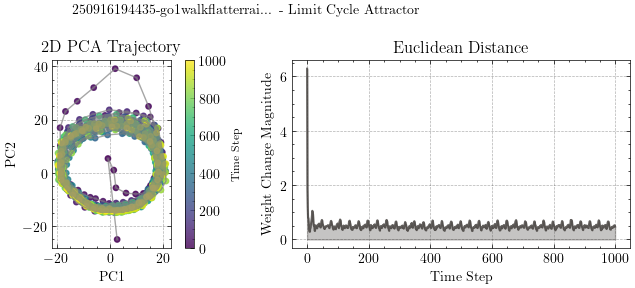

  Checkpoint 499: Limit Cycle, Max Torque: 19.94, Duty Ratio: 0.00, Fwd Vel: 0.97
Processing 2/60: 250916194446-go1walkflatterrain-mlp-hebbian-openai-es-9
Average MSE 1: 0.390435129404068, Average MSE 2: 0.08735207468271255, Threshold: 50


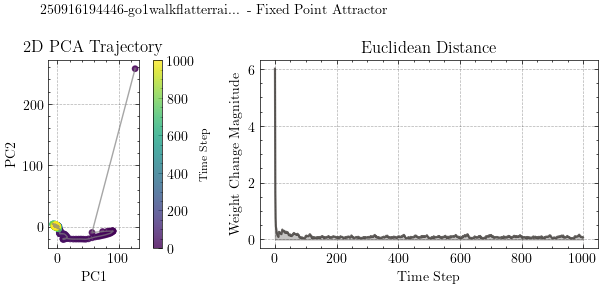

  Checkpoint 499: Fixed Point, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 0.97
Processing 3/60: 250916194503-go1walkflatterrain-mlp-hebbian-openai-es-10
Average MSE 1: 0.5720899701118469, Average MSE 2: 0.3602154850959778, Threshold: 50


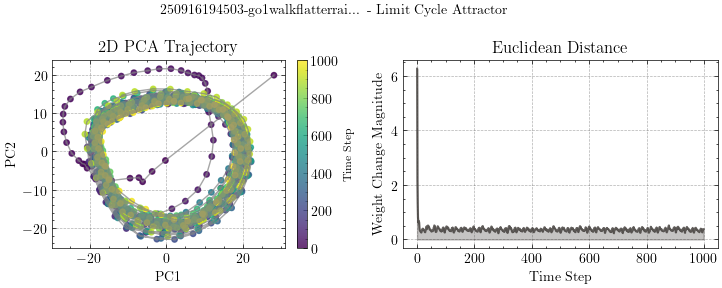

  Checkpoint 499: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 0.95
Processing 4/60: 250916194551-go1walkflatterrain-mlp-hebbian-openai-es-1
Average MSE 1: 3.7806777954101562, Average MSE 2: 2.569150686264038, Threshold: 5


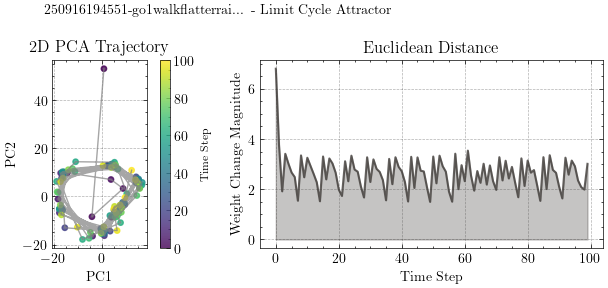

  Checkpoint 499: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 0.96
Processing 5/60: 250916194646-go1walkflatterrain-mlp-hebbian-openai-es-2
Average MSE 1: 3.4302985668182373, Average MSE 2: 1.8329633474349976, Threshold: 5


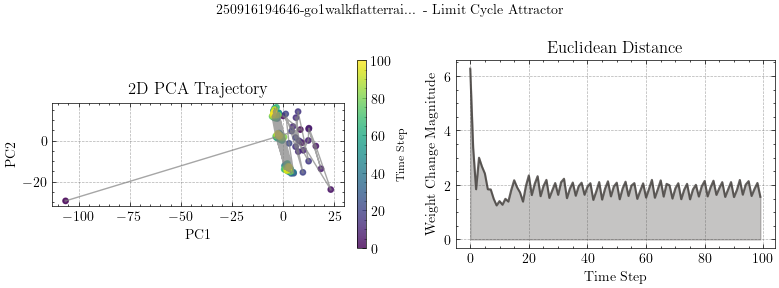

  Checkpoint 499: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 0.94
Processing 6/60: 250916194734-go1walkflatterrain-mlp-hebbian-openai-es-3
Average MSE 1: 2.4233551025390625, Average MSE 2: 0.36402127146720886, Threshold: 5


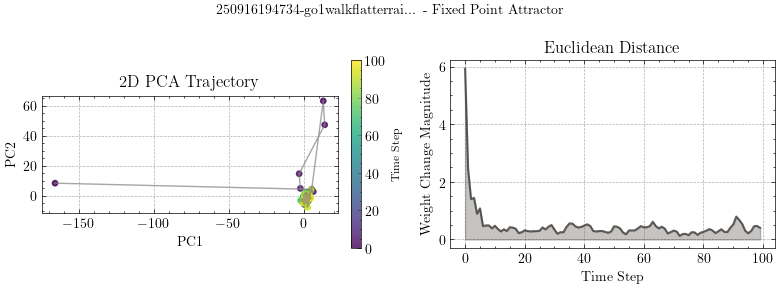

  Checkpoint 499: Fixed Point, Max Torque: 21.30, Duty Ratio: 0.00, Fwd Vel: 0.97
Processing 7/60: 250916194826-go1walkflatterrain-mlp-hebbian-openai-es-4
Average MSE 1: 2.7878565788269043, Average MSE 2: 1.2250659465789795, Threshold: 5


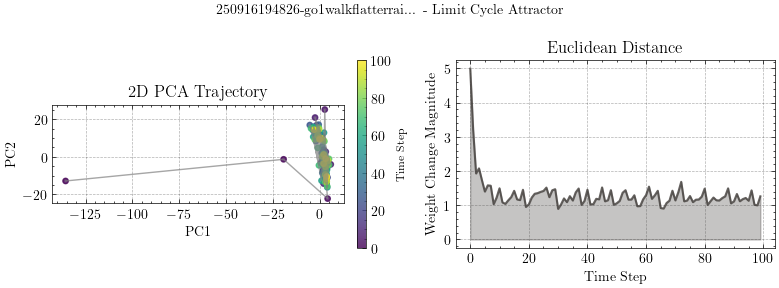

  Checkpoint 499: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 0.98
Processing 8/60: 250916194916-go1walkflatterrain-mlp-hebbian-openai-es-5
  Filtered out: Environment terminated
Processing 9/60: 250916195006-go1walkflatterrain-mlp-hebbian-openai-es-6
Average MSE 1: 2.954017400741577, Average MSE 2: 0.1848626434803009, Threshold: 5


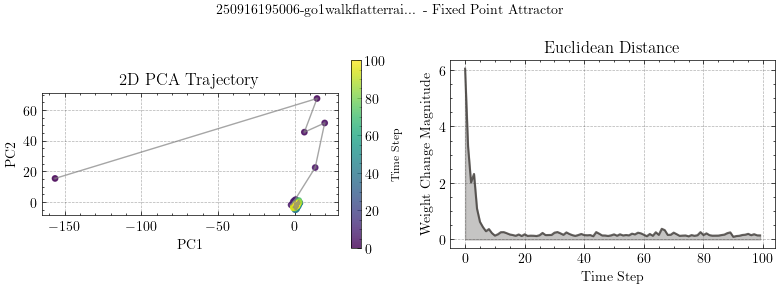

  Checkpoint 499: Fixed Point, Max Torque: 22.46, Duty Ratio: 0.00, Fwd Vel: 0.97
Processing 10/60: 250916195104-go1walkflatterrain-mlp-hebbian-openai-es-7
Average MSE 1: 2.508124828338623, Average MSE 2: 0.42156898975372314, Threshold: 5


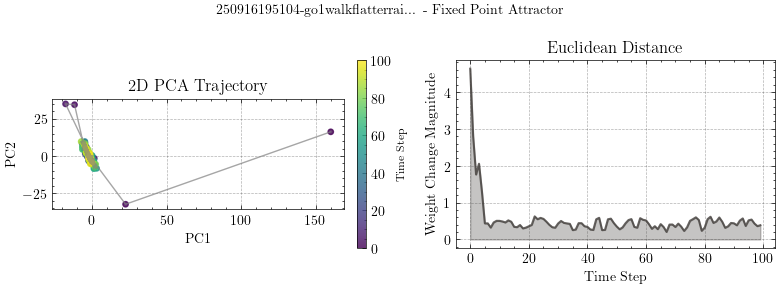

  Checkpoint 499: Fixed Point, Max Torque: 19.04, Duty Ratio: 0.00, Fwd Vel: 0.97
Processing 11/60: 250916194132-go1walkflatterrain-mlp-hebbian-openai-es-2
Average MSE 1: 1.4224038124084473, Average MSE 2: 1.2454193830490112, Threshold: 50


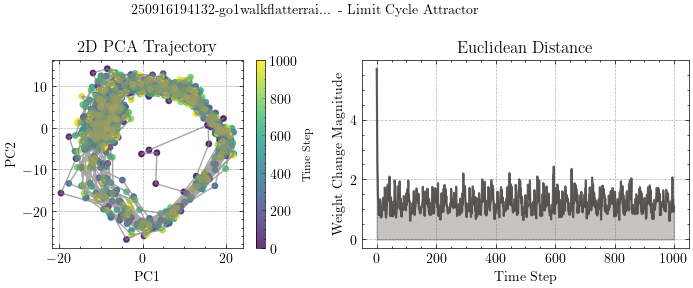

  Checkpoint 499: Limit Cycle, Max Torque: 23.48, Duty Ratio: 0.00, Fwd Vel: 0.97
Processing 12/60: 250916194132-go1walkflatterrain-mlp-hebbian-openai-es-3
Average MSE 1: 1.3775211572647095, Average MSE 2: 1.1649197340011597, Threshold: 50


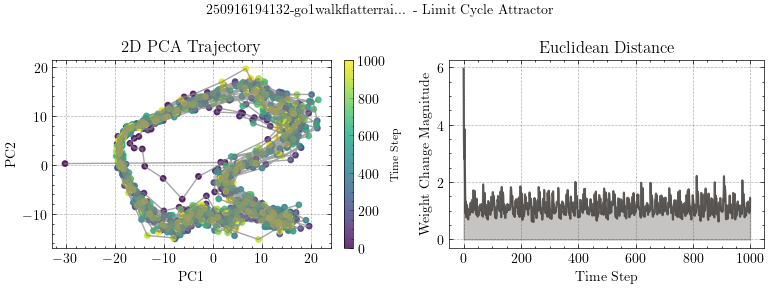

  Checkpoint 499: Limit Cycle, Max Torque: 23.36, Duty Ratio: 0.00, Fwd Vel: 0.96
Processing 13/60: 250916194132-go1walkflatterrain-mlp-hebbian-openai-es-4
Average MSE 1: 1.4632688760757446, Average MSE 2: 1.566744089126587, Threshold: 50


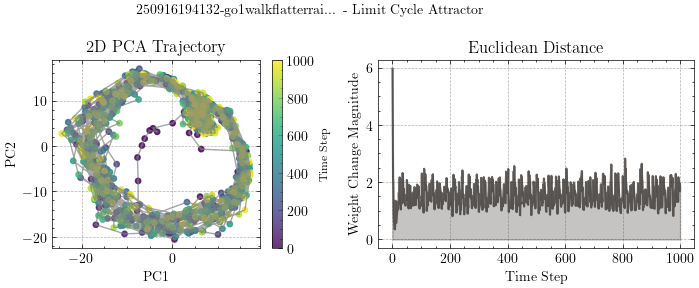

  Checkpoint 499: Limit Cycle, Max Torque: 18.36, Duty Ratio: 0.00, Fwd Vel: 0.97
Processing 14/60: 250916194213-go1walkflatterrain-mlp-hebbian-openai-es-5
Average MSE 1: 1.3830212354660034, Average MSE 2: 1.257704734802246, Threshold: 50


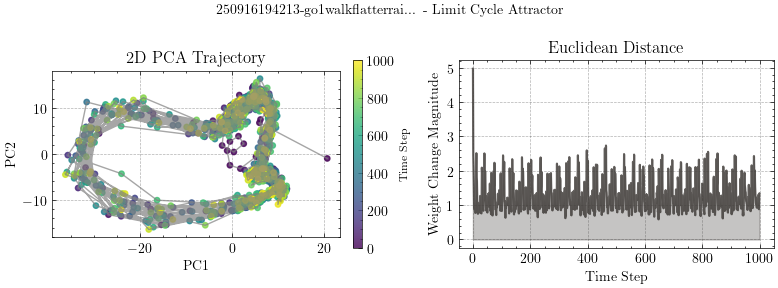

  Checkpoint 499: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 0.98
Processing 15/60: 250916194231-go1walkflatterrain-mlp-hebbian-openai-es-6
Average MSE 1: 0.9986834526062012, Average MSE 2: 1.081096887588501, Threshold: 50


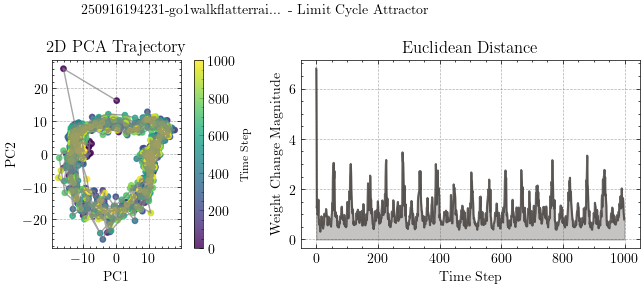

  Checkpoint 499: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 0.50
Processing 16/60: 250916194333-go1walkflatterrain-mlp-hebbian-openai-es-7
Average MSE 1: 1.4477118253707886, Average MSE 2: 1.2733997106552124, Threshold: 50


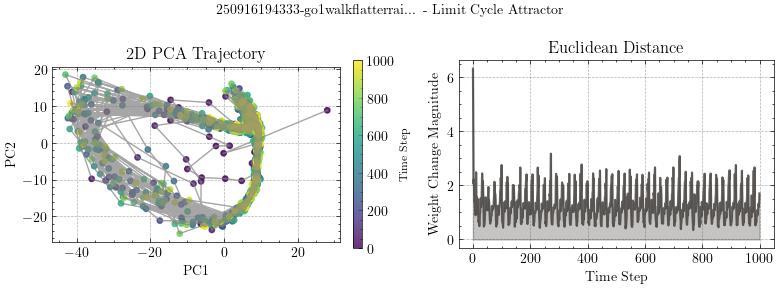

  Checkpoint 499: Limit Cycle, Max Torque: 19.88, Duty Ratio: 0.00, Fwd Vel: 0.98
Processing 17/60: 250916195736-go1walkflatterrain-mlp-hebbian-openai-es-1
Average MSE 1: 1.3434550762176514, Average MSE 2: 1.31814444065094, Threshold: 50


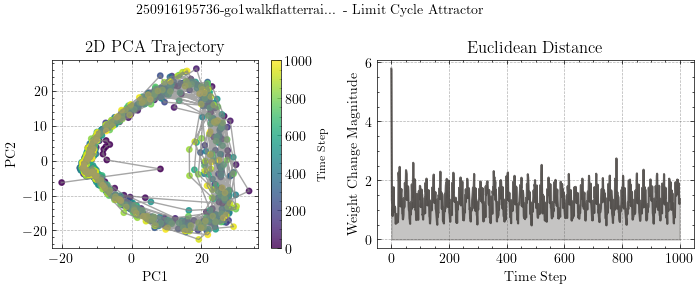

  Checkpoint 499: Limit Cycle, Max Torque: 20.94, Duty Ratio: 0.00, Fwd Vel: 0.98
Processing 18/60: 250917002822-go1walkflatterrain-mlp-hebbian-openai-es-1
Average MSE 1: 2.7398288249969482, Average MSE 2: 0.6225711107254028, Threshold: 5


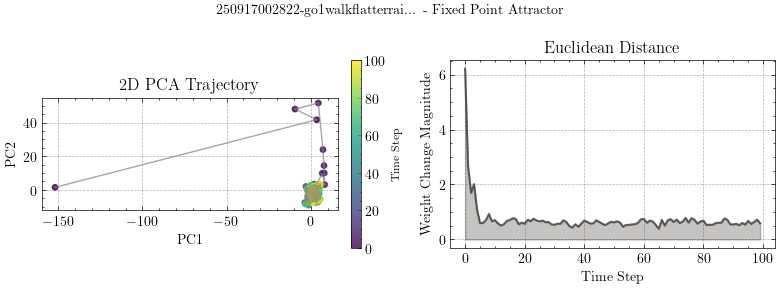

  Checkpoint 500: Fixed Point, Max Torque: 23.47, Duty Ratio: 0.00, Fwd Vel: 1.45
Processing 19/60: 250917002822-go1walkflatterrain-mlp-hebbian-openai-es-2
Average MSE 1: 3.114147186279297, Average MSE 2: 1.5967137813568115, Threshold: 5


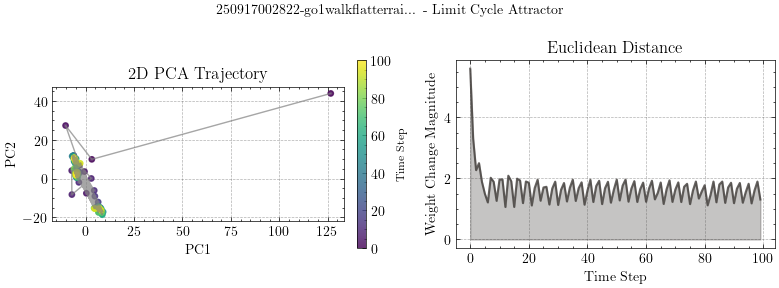

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.44
Processing 20/60: 250917002822-go1walkflatterrain-mlp-hebbian-openai-es-3
  Filtered out: Environment terminated
Processing 21/60: 250917002822-go1walkflatterrain-mlp-hebbian-openai-es-4
Average MSE 1: 3.050015926361084, Average MSE 2: 2.2980661392211914, Threshold: 5


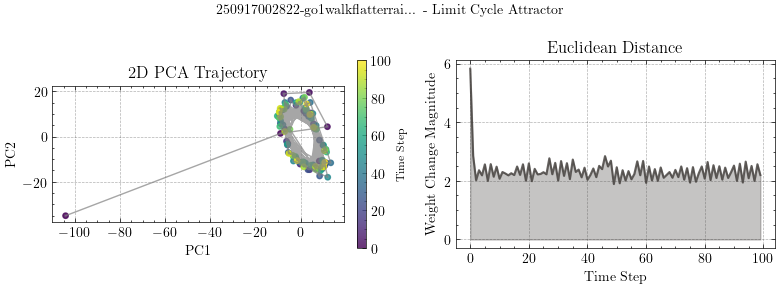

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.38
Processing 22/60: 250917002822-go1walkflatterrain-mlp-hebbian-openai-es-5
Average MSE 1: 2.8057808876037598, Average MSE 2: 0.5894981622695923, Threshold: 5


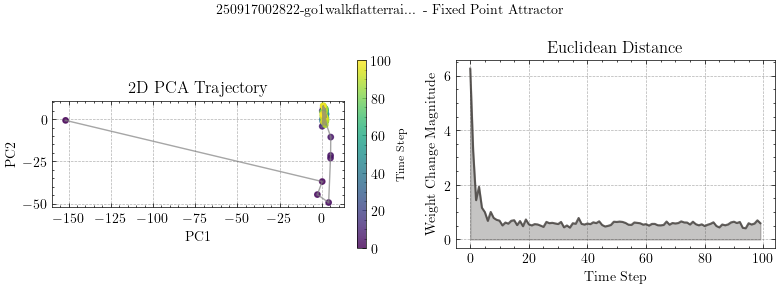

  Checkpoint 500: Fixed Point, Max Torque: 19.91, Duty Ratio: 0.00, Fwd Vel: 1.44
Processing 23/60: 250917002822-go1walkflatterrain-mlp-hebbian-openai-es-6
  Filtered out: Environment terminated
Processing 24/60: 250917002822-go1walkflatterrain-mlp-hebbian-openai-es-7
Average MSE 1: 3.3694801330566406, Average MSE 2: 1.4358868598937988, Threshold: 5


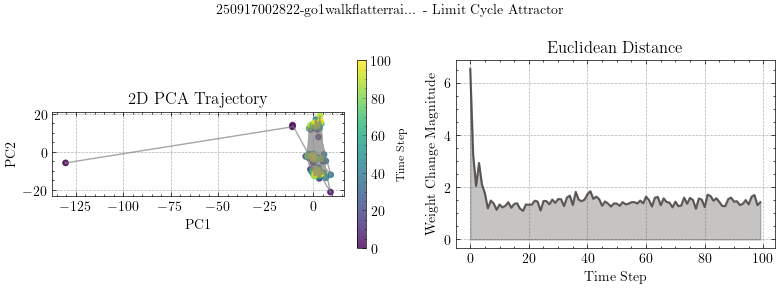

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.43
Processing 25/60: 250917002822-go1walkflatterrain-mlp-hebbian-openai-es-8
Average MSE 1: 3.142732858657837, Average MSE 2: 1.5950452089309692, Threshold: 5


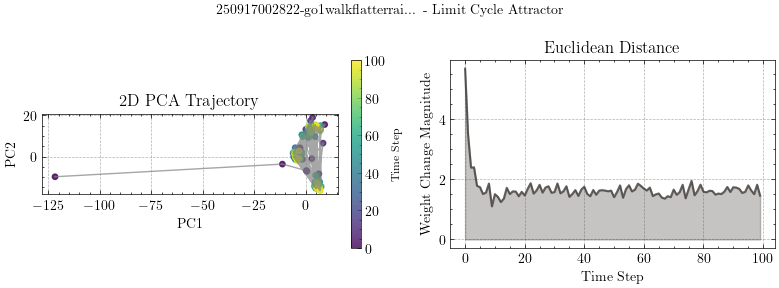

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.44
Processing 26/60: 250917002822-go1walkflatterrain-mlp-hebbian-openai-es-9
Average MSE 1: 2.709747314453125, Average MSE 2: 2.123016119003296, Threshold: 5


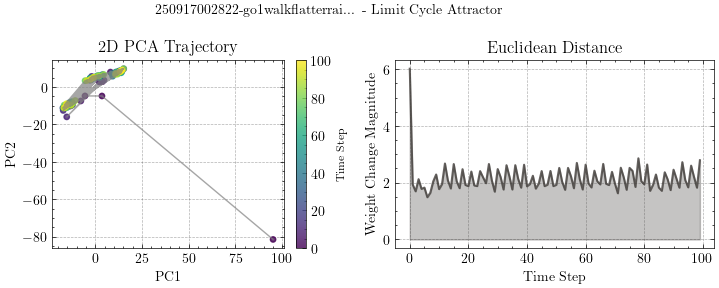

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.40
Processing 27/60: 250917002822-go1walkflatterrain-mlp-hebbian-openai-es-10
Average MSE 1: 2.32305645942688, Average MSE 2: 0.6441518664360046, Threshold: 5


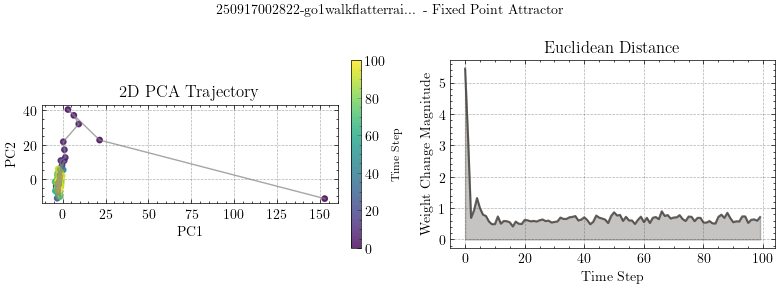

  Checkpoint 500: Fixed Point, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.41
Processing 28/60: 250917002902-go1walkflatterrain-mlp-hebbian-openai-es-1
Average MSE 1: 2.6698060035705566, Average MSE 2: 1.551724910736084, Threshold: 5


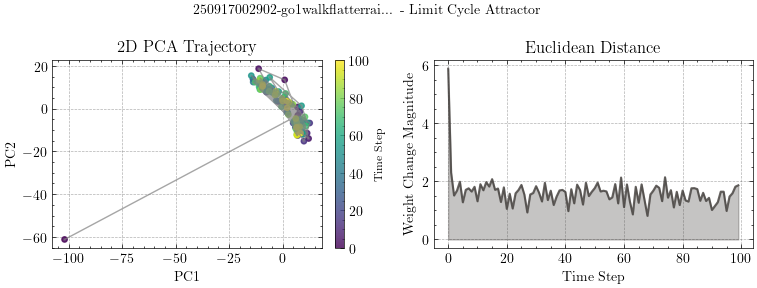

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.50
Processing 29/60: 250917002902-go1walkflatterrain-mlp-hebbian-openai-es-2
Average MSE 1: 3.5192699432373047, Average MSE 2: 3.230592966079712, Threshold: 5


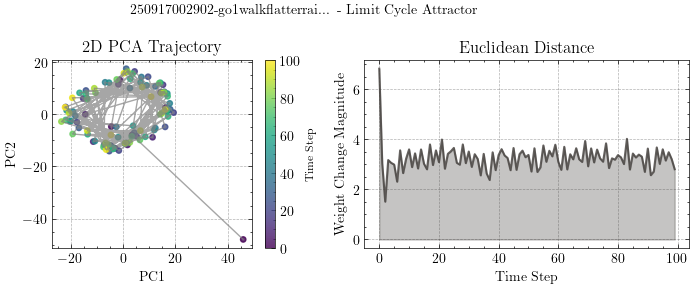

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.57
Processing 30/60: 250917002902-go1walkflatterrain-mlp-hebbian-openai-es-3
Average MSE 1: 3.547074556350708, Average MSE 2: 3.325080394744873, Threshold: 5


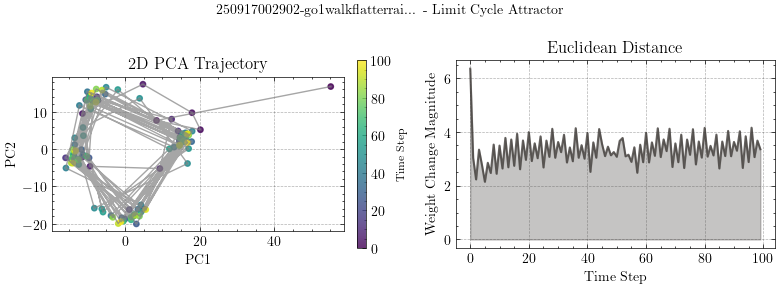

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.26
Processing 31/60: 250917002902-go1walkflatterrain-mlp-hebbian-openai-es-4
Average MSE 1: 4.020984649658203, Average MSE 2: 3.809511423110962, Threshold: 5


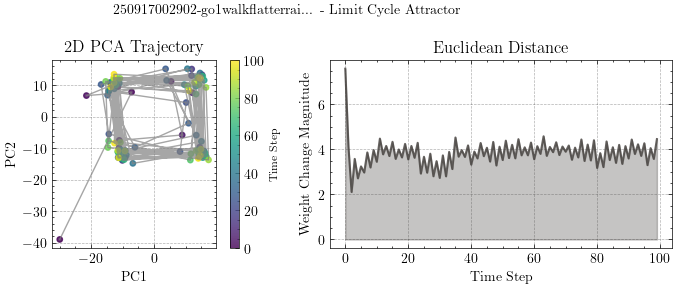

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.47
Processing 32/60: 250917002902-go1walkflatterrain-mlp-hebbian-openai-es-10
Average MSE 1: 6.631760597229004, Average MSE 2: 3.067988157272339, Threshold: 1
  Filtered out: Environment terminated
Processing 33/60: 250917002909-go1walkflatterrain-mlp-hebbian-openai-es-5
Average MSE 1: 4.479592323303223, Average MSE 2: 3.8453516960144043, Threshold: 5


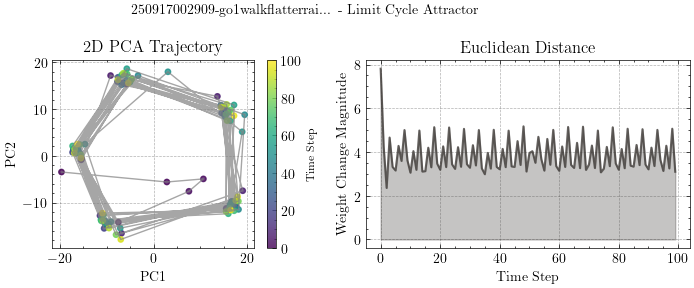

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.13
Processing 34/60: 250917002909-go1walkflatterrain-mlp-hebbian-openai-es-6
Average MSE 1: 3.8665454387664795, Average MSE 2: 3.528231620788574, Threshold: 5


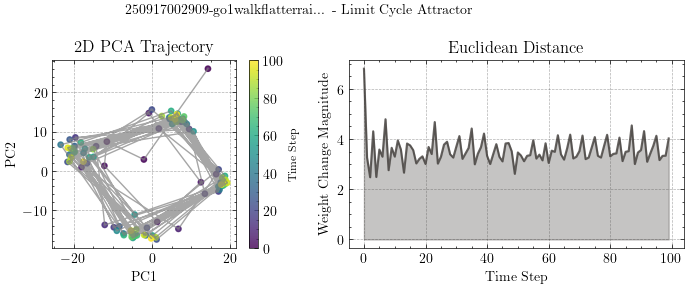

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.37
Processing 35/60: 250917002910-go1walkflatterrain-mlp-hebbian-openai-es-7
Average MSE 1: 2.608457326889038, Average MSE 2: 0.2623349130153656, Threshold: 5


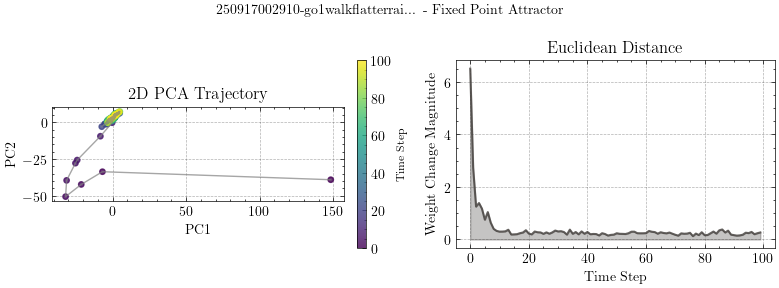

  Checkpoint 500: Fixed Point, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.92
Processing 36/60: 250917002910-go1walkflatterrain-mlp-hebbian-openai-es-8
  Filtered out: Environment terminated
Processing 37/60: 250917002910-go1walkflatterrain-mlp-hebbian-openai-es-9
Average MSE 1: 3.0871615409851074, Average MSE 2: 0.8302638530731201, Threshold: 5


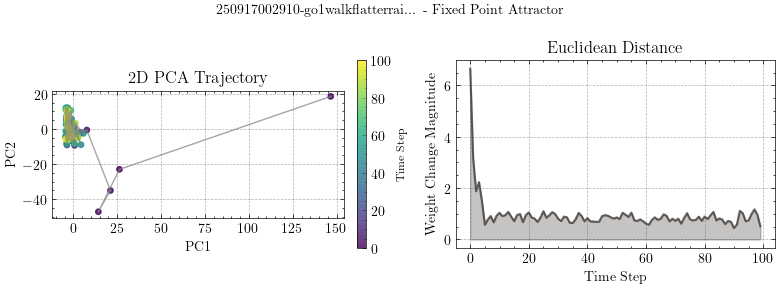

  Checkpoint 500: Fixed Point, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.93
Processing 38/60: 250917003055-go1walkflatterrain-mlp-hebbian-openai-es-1
Average MSE 1: 2.3411455154418945, Average MSE 2: 0.9604353904724121, Threshold: 3
  Filtered out: Environment terminated
Processing 39/60: 250917003055-go1walkflatterrain-mlp-hebbian-openai-es-2
Average MSE 1: 1.968231439590454, Average MSE 2: 1.4795786142349243, Threshold: 15
  Filtered out: Environment terminated
Processing 40/60: 250917015921-go1walkflatterrain-mlp-hebbian-openai-es-1
Average MSE 1: 4.338888168334961, Average MSE 2: 4.9047088623046875, Threshold: 50


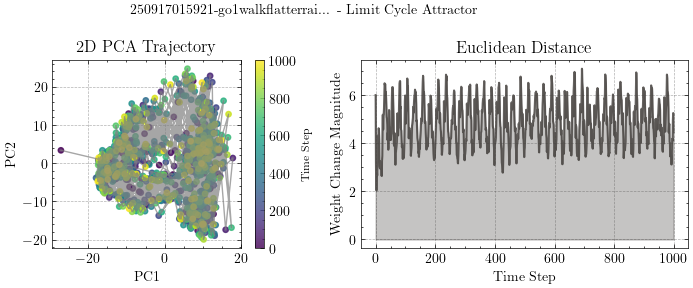

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.46
Processing 41/60: 250917015926-go1walkflatterrain-mlp-hebbian-openai-es-2
Average MSE 1: 2.8107380867004395, Average MSE 2: 1.1261578798294067, Threshold: 2
  Filtered out: Environment terminated
Processing 42/60: 250917015926-go1walkflatterrain-mlp-hebbian-openai-es-3
Average MSE 1: 1.4904202222824097, Average MSE 2: 1.5077238082885742, Threshold: 50


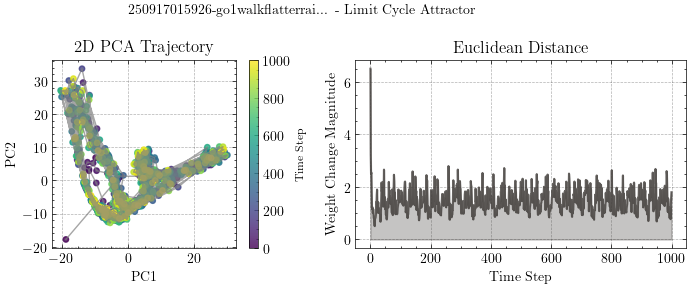

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.42
Processing 43/60: 250917015936-go1walkflatterrain-mlp-hebbian-openai-es-4
Average MSE 1: 1.5500909090042114, Average MSE 2: 1.2584675550460815, Threshold: 50


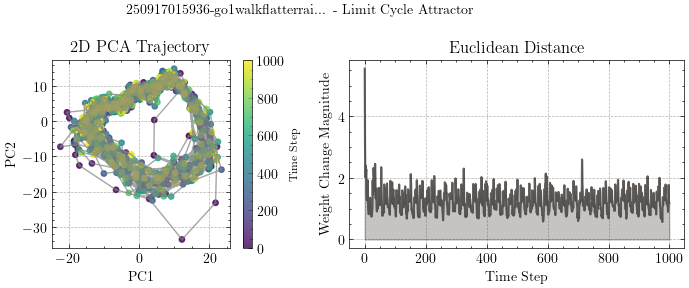

  Checkpoint 500: Limit Cycle, Max Torque: 21.23, Duty Ratio: 0.00, Fwd Vel: 1.46
Processing 44/60: 250917015947-go1walkflatterrain-mlp-hebbian-openai-es-5
Average MSE 1: 1.9137852191925049, Average MSE 2: 1.7090041637420654, Threshold: 50


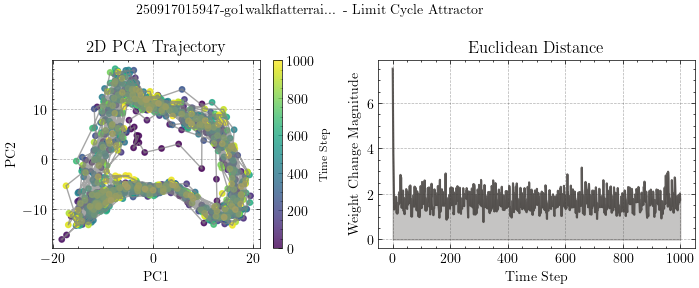

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.43
Processing 45/60: 250917015953-go1walkflatterrain-mlp-hebbian-openai-es-7
Average MSE 1: 1.1374061107635498, Average MSE 2: 1.3036102056503296, Threshold: 50


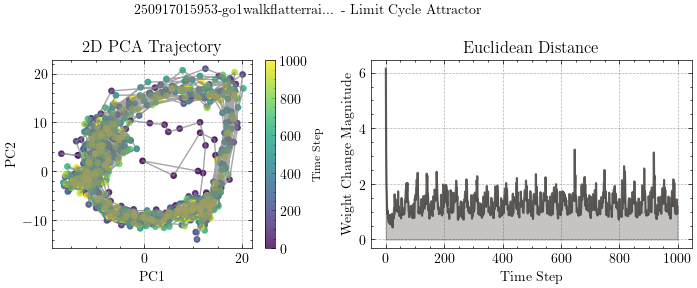

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.43
Processing 46/60: 250917015956-go1walkflatterrain-mlp-hebbian-openai-es-6
Average MSE 1: 1.970194935798645, Average MSE 2: 1.7290922403335571, Threshold: 3
  Filtered out: Environment terminated
Processing 47/60: 250917015957-go1walkflatterrain-mlp-hebbian-openai-es-8
Average MSE 1: 1.4708752632141113, Average MSE 2: 1.4766652584075928, Threshold: 50


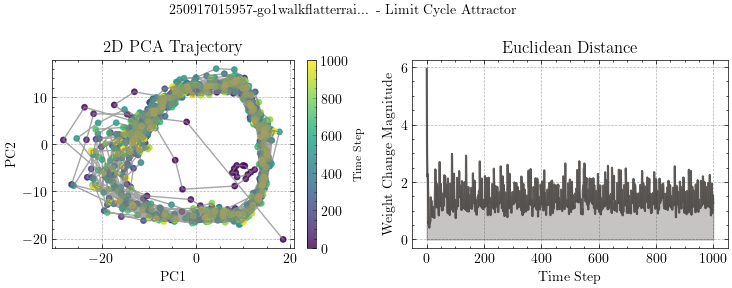

  Checkpoint 500: Limit Cycle, Max Torque: 22.52, Duty Ratio: 0.00, Fwd Vel: 1.43
Processing 48/60: 250917015958-go1walkflatterrain-mlp-hebbian-openai-es-10
Average MSE 1: 1.3944834470748901, Average MSE 2: 1.3018511533737183, Threshold: 50


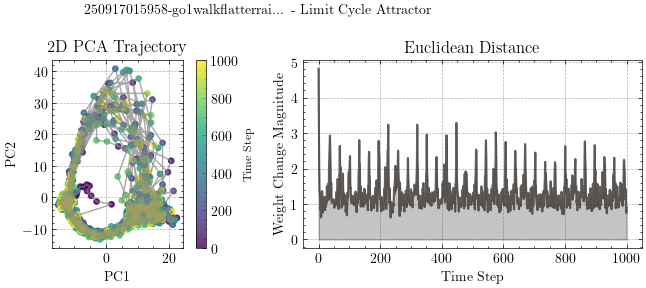

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.42
Processing 49/60: 250917020000-go1walkflatterrain-mlp-hebbian-openai-es-9
Average MSE 1: 1.4901649951934814, Average MSE 2: 1.3009406328201294, Threshold: 50


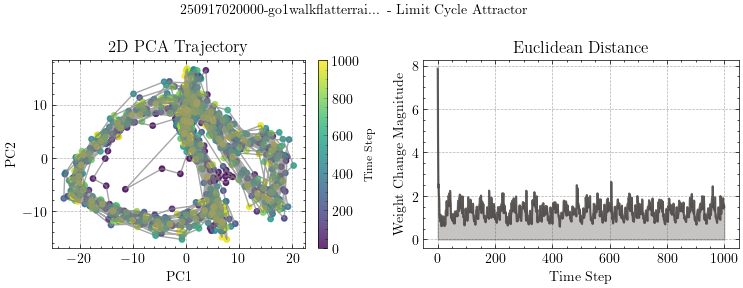

  Checkpoint 500: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.42
Processing 50/60: 250917053546-go1walkflatterrain-mlp-hebbian-openai-es-8
Average MSE 1: 1.3075315952301025, Average MSE 2: 1.276236653327942, Threshold: 50


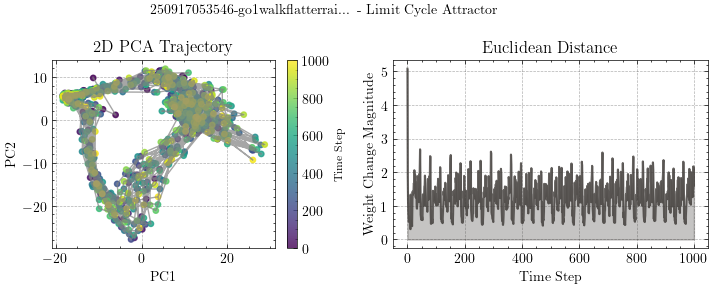

  Checkpoint 499: Limit Cycle, Max Torque: 18.12, Duty Ratio: 0.00, Fwd Vel: 0.96
Processing 51/60: 250917053551-go1walkflatterrain-mlp-hebbian-openai-es-9
Average MSE 1: 1.52996027469635, Average MSE 2: 1.4833601713180542, Threshold: 50


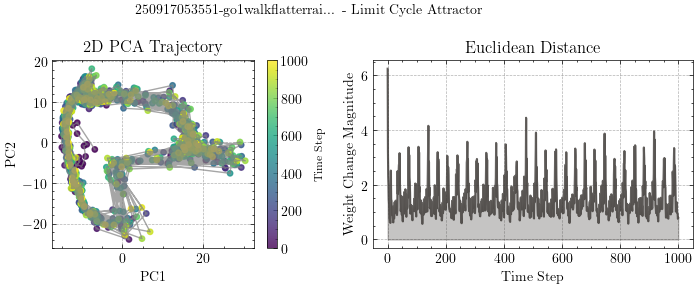

  Checkpoint 499: Limit Cycle, Max Torque: 22.66, Duty Ratio: 0.00, Fwd Vel: 0.98
Processing 52/60: 250917053551-go1walkflatterrain-mlp-hebbian-openai-es-10
Average MSE 1: 1.3924843072891235, Average MSE 2: 1.1724869012832642, Threshold: 50


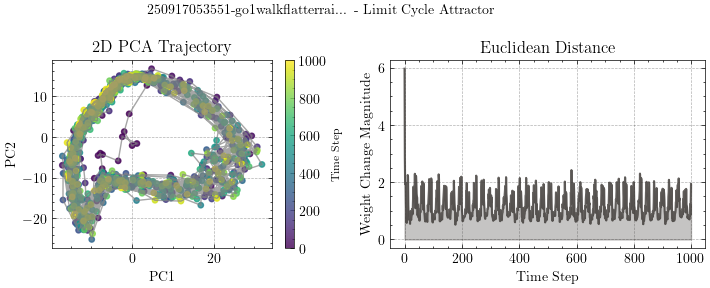

  Checkpoint 499: Limit Cycle, Max Torque: 18.96, Duty Ratio: 0.00, Fwd Vel: 0.97
Processing 53/60: 250917051231-go1walkflatterrain-mlp-hebbian-openai-es-3
Average MSE 1: 1.7148760557174683, Average MSE 2: 1.6415599584579468, Threshold: 50


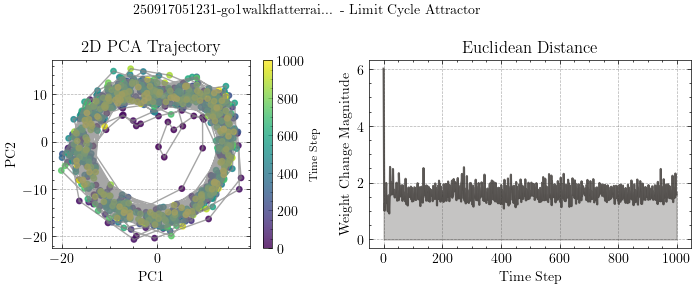

  Checkpoint 499: Limit Cycle, Max Torque: 23.34, Duty Ratio: 0.00, Fwd Vel: 1.95
Processing 54/60: 250917051231-go1walkflatterrain-mlp-hebbian-openai-es-4
Average MSE 1: 6.820111274719238, Average MSE 2: 1.443541169166565, Threshold: 1
  Filtered out: Environment terminated
Processing 55/60: 250917051231-go1walkflatterrain-mlp-hebbian-openai-es-5
Average MSE 1: 1.5898213386535645, Average MSE 2: 1.5766327381134033, Threshold: 50


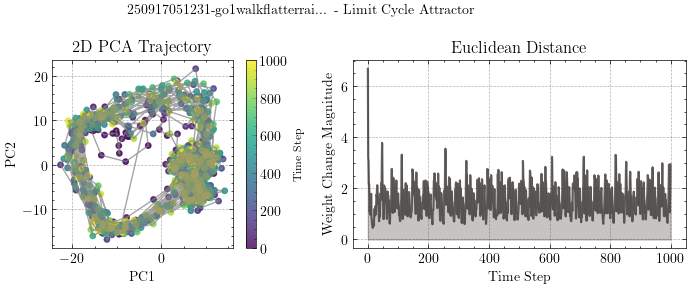

  Checkpoint 499: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.73
Processing 56/60: 250917051231-go1walkflatterrain-mlp-hebbian-openai-es-6
Average MSE 1: 5.2798943519592285, Average MSE 2: 1.5824317932128906, Threshold: 1
  Filtered out: Environment terminated
Processing 57/60: 250917051231-go1walkflatterrain-mlp-hebbian-openai-es-7
Average MSE 1: 3.2320408821105957, Average MSE 2: 1.4170023202896118, Threshold: 2
  Filtered out: Environment terminated
Processing 58/60: 250917051231-go1walkflatterrain-mlp-hebbian-openai-es-8
Average MSE 1: 1.7813694477081299, Average MSE 2: 1.6915321350097656, Threshold: 50


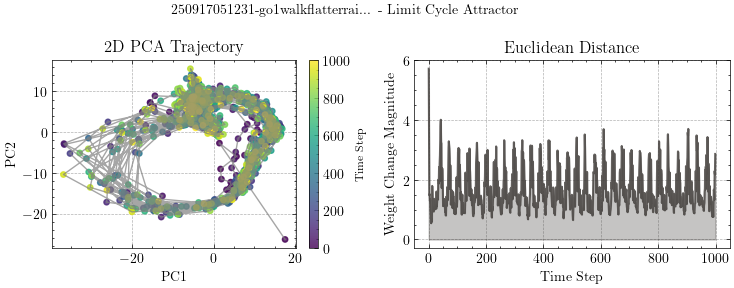

  Checkpoint 499: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.70
Processing 59/60: 250917051231-go1walkflatterrain-mlp-hebbian-openai-es-9
Average MSE 1: 3.753173351287842, Average MSE 2: 1.2928156852722168, Threshold: 2
  Filtered out: Environment terminated
Processing 60/60: 250917051231-go1walkflatterrain-mlp-hebbian-openai-es-10
Average MSE 1: 1.8719111680984497, Average MSE 2: 1.7458722591400146, Threshold: 50


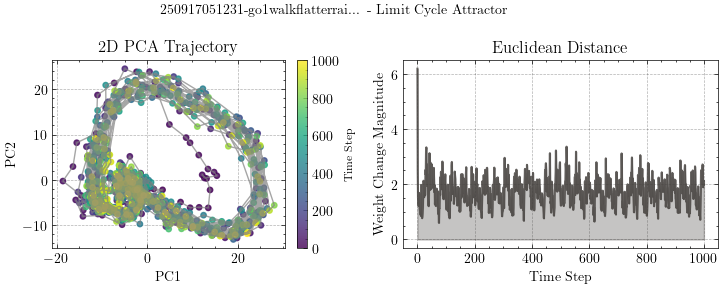

  Checkpoint 499: Limit Cycle, Max Torque: 23.70, Duty Ratio: 0.00, Fwd Vel: 1.75

Completed evaluation:
Total runs processed: 60
Filtered out (termination): 13
Filtered out (low velocity): 0
Valid runs analyzed: 47

Summary:
Fixed Point Attractors: 9
Limit Cycle Attractors: 38
Mean Max Torque: 22.77 ± 1.68
Mean Duty Ratio: 0.00 ± 0.00
Mean Angular Velocity: 1.20 ± 0.30
Mean Swing Peak: 0.05 ± 0.02
Mean Feet Air Time: 0.07 ± 0.03

Results saved to: /home/alexanderdittrich/Downloads/xebec/evaluation_results.csv

First 5 results:
                                                run_name  is_fixed_point  max_torque  duty_ratio  mean_angular_velocity  avg_forward_velocity
 250916194435-go1walkflatterrain-mlp-hebbian-openai-es-8           False   19.939331         0.0               0.896713              0.973843
 250916194446-go1walkflatterrain-mlp-hebbian-openai-es-9            True   23.700001         0.0               0.827992              0.973091
250916194503-go1walkflatterrain-mlp-hebb

In [4]:
# Main execution: Evaluate all runs in a directory
import pathlib
import pandas as pd

# Configuration
base_directory = (
    "/home/alexanderdittrich/Downloads/xebec/"  # Change this to your directory
)
episode_length = 1000
seed = 0
min_forward_velocity = 0.2  # Minimum average forward velocity threshold

# Hardcoded run names from the original experiment
EXPERIMENT_RUN_NAMES = [
    "250916194435-go1walkflatterrain-mlp-hebbian-openai-es-8",
    "250916194446-go1walkflatterrain-mlp-hebbian-openai-es-9",
    "250916194503-go1walkflatterrain-mlp-hebbian-openai-es-10",
    "250916194551-go1walkflatterrain-mlp-hebbian-openai-es-1",
    "250916194646-go1walkflatterrain-mlp-hebbian-openai-es-2",
    "250916194734-go1walkflatterrain-mlp-hebbian-openai-es-3",
    "250916194826-go1walkflatterrain-mlp-hebbian-openai-es-4",
    "250916194916-go1walkflatterrain-mlp-hebbian-openai-es-5",
    "250916195006-go1walkflatterrain-mlp-hebbian-openai-es-6",
    "250916195104-go1walkflatterrain-mlp-hebbian-openai-es-7",
    "250916194132-go1walkflatterrain-mlp-hebbian-openai-es-2",
    "250916194132-go1walkflatterrain-mlp-hebbian-openai-es-3",
    "250916194132-go1walkflatterrain-mlp-hebbian-openai-es-4",
    "250916194213-go1walkflatterrain-mlp-hebbian-openai-es-5",
    "250916194231-go1walkflatterrain-mlp-hebbian-openai-es-6",
    "250916194333-go1walkflatterrain-mlp-hebbian-openai-es-7",
    "250916195736-go1walkflatterrain-mlp-hebbian-openai-es-1",
    "250917002822-go1walkflatterrain-mlp-hebbian-openai-es-1",
    "250917002822-go1walkflatterrain-mlp-hebbian-openai-es-2",
    "250917002822-go1walkflatterrain-mlp-hebbian-openai-es-3",
    "250917002822-go1walkflatterrain-mlp-hebbian-openai-es-4",
    "250917002822-go1walkflatterrain-mlp-hebbian-openai-es-5",
    "250917002822-go1walkflatterrain-mlp-hebbian-openai-es-6",
    "250917002822-go1walkflatterrain-mlp-hebbian-openai-es-7",
    "250917002822-go1walkflatterrain-mlp-hebbian-openai-es-8",
    "250917002822-go1walkflatterrain-mlp-hebbian-openai-es-9",
    "250917002822-go1walkflatterrain-mlp-hebbian-openai-es-10",
    "250917002902-go1walkflatterrain-mlp-hebbian-openai-es-1",
    "250917002902-go1walkflatterrain-mlp-hebbian-openai-es-2",
    "250917002902-go1walkflatterrain-mlp-hebbian-openai-es-3",
    "250917002902-go1walkflatterrain-mlp-hebbian-openai-es-4",
    "250917002902-go1walkflatterrain-mlp-hebbian-openai-es-10",
    "250917002909-go1walkflatterrain-mlp-hebbian-openai-es-5",
    "250917002909-go1walkflatterrain-mlp-hebbian-openai-es-6",
    "250917002910-go1walkflatterrain-mlp-hebbian-openai-es-7",
    "250917002910-go1walkflatterrain-mlp-hebbian-openai-es-8",
    "250917002910-go1walkflatterrain-mlp-hebbian-openai-es-9",
    "250917003055-go1walkflatterrain-mlp-hebbian-openai-es-1",
    "250917003055-go1walkflatterrain-mlp-hebbian-openai-es-2",
    "250917015921-go1walkflatterrain-mlp-hebbian-openai-es-1",
    "250917015926-go1walkflatterrain-mlp-hebbian-openai-es-2",
    "250917015926-go1walkflatterrain-mlp-hebbian-openai-es-3",
    "250917015936-go1walkflatterrain-mlp-hebbian-openai-es-4",
    "250917015947-go1walkflatterrain-mlp-hebbian-openai-es-5",
    "250917015953-go1walkflatterrain-mlp-hebbian-openai-es-7",
    "250917015956-go1walkflatterrain-mlp-hebbian-openai-es-6",
    "250917015957-go1walkflatterrain-mlp-hebbian-openai-es-8",
    "250917015958-go1walkflatterrain-mlp-hebbian-openai-es-10",
    "250917020000-go1walkflatterrain-mlp-hebbian-openai-es-9",
    "250917053546-go1walkflatterrain-mlp-hebbian-openai-es-8",
    "250917053551-go1walkflatterrain-mlp-hebbian-openai-es-9",
    "250917053551-go1walkflatterrain-mlp-hebbian-openai-es-10",
    "250917051231-go1walkflatterrain-mlp-hebbian-openai-es-3",
    "250917051231-go1walkflatterrain-mlp-hebbian-openai-es-4",
    "250917051231-go1walkflatterrain-mlp-hebbian-openai-es-5",
    "250917051231-go1walkflatterrain-mlp-hebbian-openai-es-6",
    "250917051231-go1walkflatterrain-mlp-hebbian-openai-es-7",
    "250917051231-go1walkflatterrain-mlp-hebbian-openai-es-8",
    "250917051231-go1walkflatterrain-mlp-hebbian-openai-es-9",
    "250917051231-go1walkflatterrain-mlp-hebbian-openai-es-10",
]

# Filter only runs that exist in base_directory
base_path = pathlib.Path(base_directory)
run_dirs = []
missing = []
for name in EXPERIMENT_RUN_NAMES:
    p = base_path / name
    if p.is_dir():
        run_dirs.append(str(p))
    else:
        missing.append(name)

print(
    f"Found {len(run_dirs)}/{len(EXPERIMENT_RUN_NAMES)} run directories in {base_directory}"
)
if missing:
    print(f"Missing ({len(missing)}): {missing}")

# Evaluate all runs
results = []
filtered_count = 0
termination_filtered = 0
velocity_filtered = 0

for i, run_dir in enumerate(run_dirs):
    print(f"Processing {i + 1}/{len(run_dirs)}: {pathlib.Path(run_dir).name}")

    # Load checkpoint
    checkpoint_data = load_checkpoint(run_dir)
    if checkpoint_data is None:
        print(f"  Failed to load checkpoint")
        continue

    # Evaluate
    try:
        eval_results = evaluate_single_run(
            checkpoint_data, episode_length, seed
        )
        metrics = compute_metrics(eval_results)

        # Apply filtering criteria
        if metrics.get("terminated", False):
            print(f"  Filtered out: Environment terminated")
            termination_filtered += 1
            continue

        if metrics.get("avg_forward_velocity", 0.0) < min_forward_velocity:
            print(
                f"  Filtered out: Forward velocity {metrics.get('avg_forward_velocity', 0.0):.3f} < {min_forward_velocity}"
            )
            velocity_filtered += 1
            continue

        # Generate validation plots for attractor estimation
        run_name = pathlib.Path(run_dir).name
        plot_attractor_validation(
            eval_results["weight_history"],
            run_name,
            metrics.get("is_fixed_point", True),
        )

        # Add metadata
        run_parts = run_name.split("-")

        result = {
            "run_name": run_name,
            "run_dir": run_dir,
            "checkpoint": checkpoint_data["checkpoint"],
            "timestamp": run_parts[0] if len(run_parts) > 0 else "unknown",
            "environment": run_parts[1] if len(run_parts) > 1 else "unknown",
            "policy_type": run_parts[2] if len(run_parts) > 2 else "unknown",
            "strategy_type": run_parts[3] if len(run_parts) > 3 else "unknown",
            "seed": int(run_parts[4])
            if len(run_parts) > 4 and run_parts[4].isdigit()
            else 0,
            **metrics,
        }

        results.append(result)

        # Print key metrics
        attractor_type = (
            "Fixed Point"
            if metrics.get("is_fixed_point", True)
            else "Limit Cycle"
        )
        print(
            f"  Checkpoint {checkpoint_data['checkpoint']}: {attractor_type}, Max Torque: {metrics.get('max_torque', 0):.2f}, Duty Ratio: {metrics.get('duty_ratio', 0):.2f}, Fwd Vel: {metrics.get('avg_forward_velocity', 0):.2f}"
        )

    except Exception as e:
        print(f"  Evaluation failed: {e}")

# Create results DataFrame
results_df = pd.DataFrame(results)
print(f"\nCompleted evaluation:")
print(f"Total runs processed: {len(run_dirs)}")
print(f"Filtered out (termination): {termination_filtered}")
print(f"Filtered out (low velocity): {velocity_filtered}")
print(f"Valid runs analyzed: {len(results_df)}")

# Summary statistics
if len(results_df) > 0:
    print(f"\nSummary:")
    print(f"Fixed Point Attractors: {results_df['is_fixed_point'].sum()}")
    print(f"Limit Cycle Attractors: {(~results_df['is_fixed_point']).sum()}")
    print(
        f"Mean Max Torque: {results_df['max_torque'].mean():.2f} ± {results_df['max_torque'].std():.2f}"
    )
    print(
        f"Mean Duty Ratio: {results_df['duty_ratio'].mean():.2f} ± {results_df['duty_ratio'].std():.2f}"
    )
    print(
        f"Mean Angular Velocity: {results_df['mean_angular_velocity'].mean():.2f} ± {results_df['mean_angular_velocity'].std():.2f}"
    )
    print(
        f"Mean Swing Peak: {results_df['mean_swing_peak'].mean():.2f} ± {results_df['mean_swing_peak'].std():.2f}"
    )
    print(
        f"Mean Feet Air Time: {results_df['mean_feet_air_time'].mean():.2f} ± {results_df['mean_feet_air_time'].std():.2f}"
    )

    # Save results
    output_file = base_path / "evaluation_results.csv"
    results_df.to_csv(output_file, index=False)
    print(f"\nResults saved to: {output_file}")

    # Display first few rows
    print(f"\nFirst 5 results:")
    print(
        results_df[
            [
                "run_name",
                "is_fixed_point",
                "max_torque",
                "duty_ratio",
                "mean_angular_velocity",
                "avg_forward_velocity",
            ]
        ]
        .head()
        .to_string(index=False)
    )
else:
    print("No successful evaluations after filtering")

In [5]:
# Enrich results_df with activation_buffer_cls from metadata.yaml (no recomputation needed)
import yaml


def read_activation_buffer_cls(run_dir):
    metadata_path = pathlib.Path(run_dir) / "metadata.yaml"
    if not metadata_path.exists():
        return "unknown"
    with open(metadata_path) as f:
        meta = yaml.safe_load(f)
    return meta.get("policy", {}).get("activation_buffer_cls", "unknown")


results_df["activation_buffer_cls"] = results_df["run_dir"].apply(
    read_activation_buffer_cls
)
print(
    results_df[
        ["run_name", "is_fixed_point", "activation_buffer_cls"]
    ].to_string(index=False)
)

                                                run_name  is_fixed_point activation_buffer_cls
 250916194435-go1walkflatterrain-mlp-hebbian-openai-es-8           False        moving-average
 250916194446-go1walkflatterrain-mlp-hebbian-openai-es-9            True        moving-average
250916194503-go1walkflatterrain-mlp-hebbian-openai-es-10           False        moving-average
 250916194551-go1walkflatterrain-mlp-hebbian-openai-es-1           False        moving-average
 250916194646-go1walkflatterrain-mlp-hebbian-openai-es-2           False        moving-average
 250916194734-go1walkflatterrain-mlp-hebbian-openai-es-3            True        moving-average
 250916194826-go1walkflatterrain-mlp-hebbian-openai-es-4           False        moving-average
 250916195006-go1walkflatterrain-mlp-hebbian-openai-es-6            True        moving-average
 250916195104-go1walkflatterrain-mlp-hebbian-openai-es-7            True        moving-average
 250916194132-go1walkflatterrain-mlp-hebbian-opena

Saved to: attractor_analysis.pdf


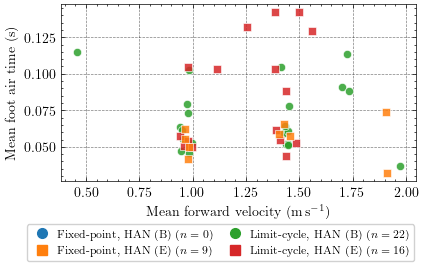

In [10]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(4.4, 3.2))

GROUPS = {
    ("fixed_point", "direct"): ("o", "#1f77b4", "Fixed-point, HAN (B)"),
    ("fixed_point", "moving-average"): (
        "s",
        "#ff7f0e",
        "Fixed-point, HAN (E)",
    ),
    ("limit_cycle", "direct"): ("o", "#2ca02c", "Limit-cycle, HAN (B)"),
    ("limit_cycle", "moving-average"): (
        "s",
        "#d62728",
        "Limit-cycle, HAN (E)",
    ),
}

# Draw order: purple last so it appears on top
DRAW_ORDER = [
    (True, "direct"),
    (False, "direct"),
    (False, "moving-average"),
    (True, "moving-average"),  # purple on top
]

# Legend order: logical grouping
LEGEND_ORDER = [
    (True, "direct"),
    (True, "moving-average"),
    (False, "direct"),
    (False, "moving-average"),
]

rng = np.random.default_rng(42)

for fp, buf_key in DRAW_ORDER:
    fp_key = "fixed_point" if fp else "limit_cycle"
    marker, color, label = GROUPS[(fp_key, buf_key)]
    mask = (results_df["is_fixed_point"] == fp) & (
        results_df["activation_buffer_cls"] == buf_key
    )
    sub = results_df[mask]
    if not sub.empty:
        n = len(sub)
        x = sub["forward_velocity"].values + rng.normal(0, 0.02, n)
        y = sub["mean_feet_air_time"].values + rng.normal(0, 0.002, n)
        ax.scatter(
            x,
            y,
            s=35,
            alpha=0.85,
            marker=marker,
            color=color,
            edgecolors="white",
            linewidths=0.5,
            rasterized=True,
        )

legend_elements = []
for fp, buf_key in LEGEND_ORDER:
    fp_key = "fixed_point" if fp else "limit_cycle"
    marker, color, label = GROUPS[(fp_key, buf_key)]
    mask = (results_df["is_fixed_point"] == fp) & (
        results_df["activation_buffer_cls"] == buf_key
    )
    n = (mask).sum()
    legend_elements.append(
        Line2D(
            [0],
            [0],
            marker=marker,
            color="w",
            markerfacecolor=color,
            markeredgecolor=color,
            markersize=7,
            label=f"{label} ($n={n}$)",
        )
    )

ax.set_xlabel(r"Mean forward velocity ($\mathrm{m\,s^{-1}}$)")
ax.set_ylabel(r"Mean foot air time ($\mathrm{s}$)")

ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.45, -0.48),
    ncol=2,
    fontsize=8,
    frameon=True,
    framealpha=0.9,
    handletextpad=0.3,
    columnspacing=1.0,
)

fig.tight_layout()
fig.savefig("attractor_analysis.pdf", bbox_inches="tight", dpi=300)
print("Saved to: attractor_analysis.pdf")
plt.show()